Isolated points detected: 1 at positions [(14, 10)]
Boundary pixels: 69, Interior pixels: 12
Hole filled: 9 pixels added

Connected components: 5
  C1 (Filled square): 51 px <-- largest
  C2 (Rectangle): 27 px
  C3 (L-shape): 1 px
  C4 (Diagonal line): 1 px
  C5 (Isolated point): 1 px


/var/folders/13/gmr0kn5s3vg4849g2jq7356h0000gq/T/ipykernel_1575/1085140986.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  comp_colors = plt.cm.get_cmap('Set1', n + 1)


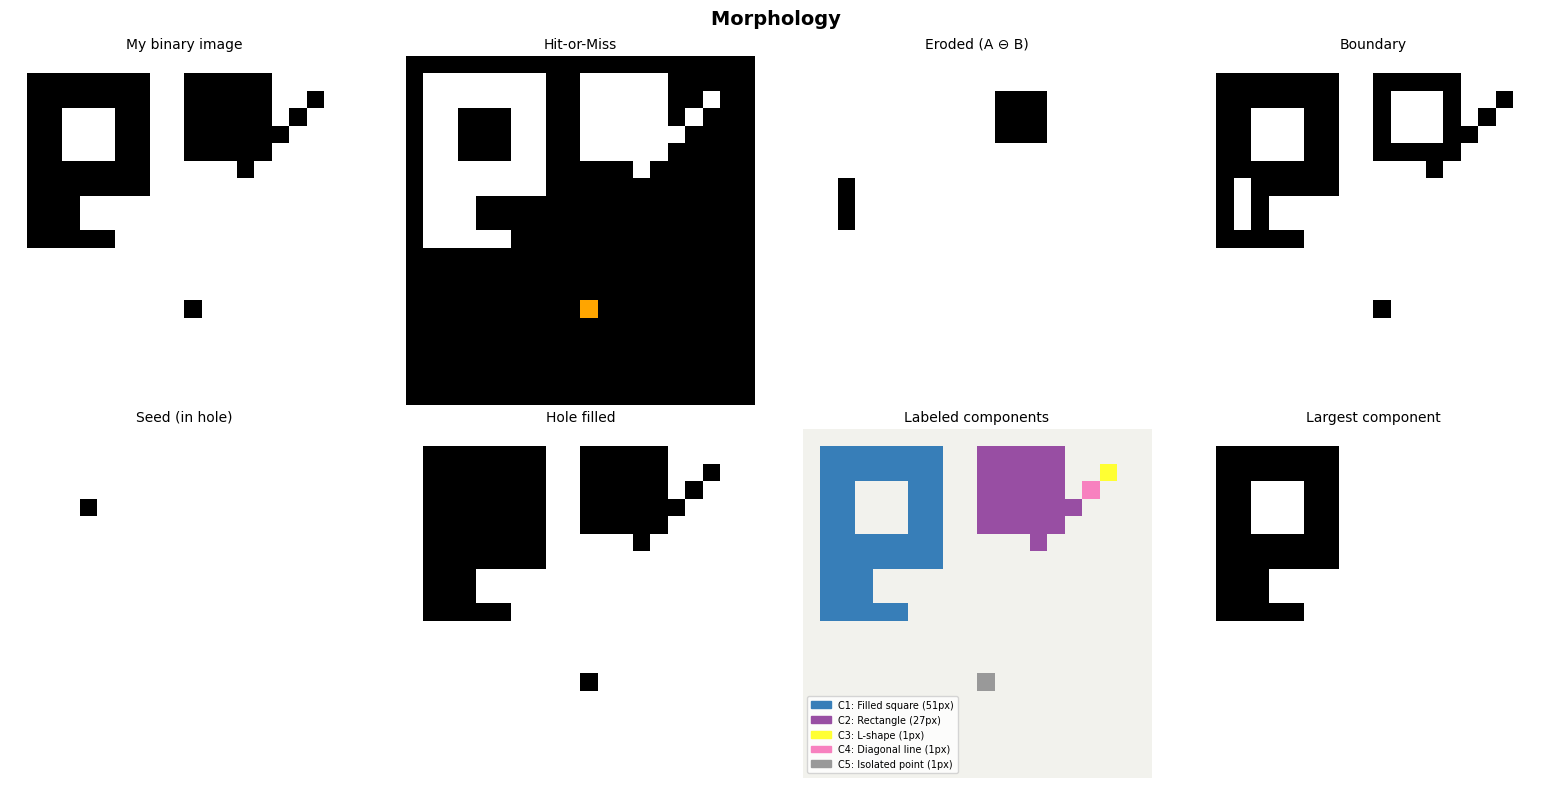

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import ndimage

#BUILD THE IMAGE
img = np.zeros((20, 20), dtype=np.uint8)

# square with a hole
for r in range(1, 8):
    for c in range(1, 8):
        img[r, c] = 1
for r in range(3, 6):
    for c in range(3, 6):
        img[r, c] = 0  # hole

#rectangle
img[1:6, 10:15] = 1

#L-shape
img[8:11, 1:4] = 1
img[10, 1:6] = 1

#diagonal line
for i in range(5):
    img[2 + i, 17 - i] = 1

#isolated point
img[14, 10] = 1

#HIT-OR-MISS for detecting isolated point
B1 = np.array([[0, 0, 0],
               [0, 1, 0],
               [0, 0, 0]], dtype=np.uint8)

B2 = np.array([[1, 1, 1],
               [1, 0, 1],
               [1, 1, 1]], dtype=np.uint8)

e1 = ndimage.binary_erosion(img, B1)
e2 = ndimage.binary_erosion(1 - img, B2)
hmt = (e1 & e2).astype(np.uint8)

matches = list(zip(*np.where(hmt == 1)))
print(f"Isolated points detected: {len(matches)} at positions {matches}")

#BOUNDARY EXTRACTION
B = np.ones((3, 3), dtype=np.uint8)
eroded = ndimage.binary_erosion(img, B).astype(np.uint8)
boundary = img - eroded

print(f"Boundary pixels: {boundary.sum()}, Interior pixels: {eroded.sum()}")

#HOLE FILLING
Ac = 1 - img
seed = np.zeros_like(img)
seed[4, 4] = 1  # seed inside the hole

B_cross = np.array([[0, 1, 0],
                    [1, 1, 1],
                    [0, 1, 0]], dtype=np.uint8)

Xk = seed.copy()
for _ in range(100):
    Xnew = ndimage.binary_dilation(Xk, B_cross).astype(np.uint8) & Ac
    if np.array_equal(Xnew, Xk):
        break
    Xk = Xnew

filled = np.clip(img + Xk, 0, 1)
print(f"Hole filled: {Xk.sum()} pixels added")

#CONNECTED COMPONENTS
labeled, n = ndimage.label(img)
areas = ndimage.sum(img, labeled, index=range(1, n + 1))
largest_label = np.argmax(areas) + 1
largest = (labeled == largest_label).astype(np.uint8)

print(f"\nConnected components: {n}")
names = ["Filled square", "Rectangle", "L-shape", "Diagonal line", "Isolated point"]
for i, (name, area) in enumerate(zip(names, areas), 1):
    marker = " <-- largest" if i == largest_label else ""
    print(f"  C{i} ({name}): {int(area)} px{marker}")

#PLOT RESULTS 
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Morphology ", fontsize=14, fontweight='bold')

#color map for labeled image
comp_colors = plt.cm.get_cmap('Set1', n + 1)
labeled_rgb = comp_colors(labeled / max(labeled.max(), 1))
labeled_rgb[labeled == 0] = [0.95, 0.95, 0.93, 1]

#hit-or-miss overlay
hmt_overlay = np.stack([img, img, img], axis=-1).astype(float)
for r, c in matches:
    hmt_overlay[r, c] = [1.0, 0.65, 0.0]  # orange

plots = [
    (img,          "My binary image",    'gray_r', False),
    (hmt_overlay,  "Hit-or-Miss",        None,     True),
    (eroded,       "Eroded (A ⊖ B)",   'gray_r', False),
    (boundary,     "Boundary",          'gray_r', False),
    (seed,         "Seed (in hole)",    'gray_r', False),
    (filled,       "Hole filled",       'gray_r', False),
    (labeled_rgb,  "Labeled components", None,     True),
    (largest,      "Largest component",  'gray_r', False),
]

for ax, (data, title, cmap, is_rgb) in zip(axes.flat, plots):
    if is_rgb:
        ax.imshow(data, interpolation='nearest')
    else:
        ax.imshow(data, cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

# legend for labeled image
legend_ax = axes[1, 2]
patches = [mpatches.Patch(color=comp_colors(i / max(n, 1)), label=f"C{i}: {names[i-1]} ({int(areas[i-1])}px)")
           for i in range(1, n + 1)]
legend_ax.legend(handles=patches, loc='lower left', fontsize=7, framealpha=0.8)

plt.tight_layout()
plt.show()